# Phase 5: Isolation Forest on Preprocessed Features

Train Isolation Forest on **modified** (preprocessed) features.

**Modifications applied (in Phase 3):**
- Modification 1: Per-machine-ID normalisation (mean subtraction)
- Modification 2: Variance-weighted MFCC selection (downweight identity-encoding coefficients)

**Goals:**
1. Evaluate AUC on modified features across all 24 configurations
2. Compare directly against Phase 4 baseline
3. Compute delta AUC (modified − baseline) to measure domain shift reduction

**Configuration:** identical to Phase 4
- n_estimators: 100, max_features: 0.8, contamination: 'auto'
- Seeds: 42–51 (same as Phase 4 — essential for fair comparison)

## Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import pickle

from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score

sys.path.insert(0, 'C:/Users/Letizia/Documents/sound-anomaly-detection/src')
from audio_loader import AudioLoader

RESULTS_DIR = Path("C:/Users/Letizia/Documents/sound-anomaly-detection/results")

print("✓ All imports successful!")
print(f"  Results dir: {RESULTS_DIR}")

✓ All imports successful!
  Results dir: C:\Users\Letizia\Documents\sound-anomaly-detection\results


## Isolation Forest Function (identical to Phase 4)

In [2]:
def run_isolation_forest(X_train, X_test, y_test, n_seeds=10, random_state_start=42):
    """
    Train Isolation Forest and average AUC across multiple seeds.
    Identical configuration to Phase 4 — only input data changes.
    """
    aucs = []
    for seed_offset in range(n_seeds):
        clf = IsolationForest(
            n_estimators=100,
            max_features=0.8,        # Feature subsampling — interacts with variance weighting
            contamination='auto',    # No effect on AUC-ROC
            random_state=random_state_start + seed_offset,
            n_jobs=-1
        )
        clf.fit(X_train)
        scores = -clf.score_samples(X_test)  # Flip: higher = more anomalous
        aucs.append(roc_auc_score(y_test, scores))

    return np.mean(aucs), np.std(aucs), aucs

print("✓ Function defined")

✓ Function defined


## Load Phase 4 Baseline Results

In [3]:
with open(RESULTS_DIR / "phase4_baseline_results.pkl", 'rb') as f:
    baseline_results = pickle.load(f)

print(f"✓ Loaded {len(baseline_results)} baseline configurations")
print(f"  Example keys: {list(baseline_results.keys())[:3]}")

✓ Loaded 24 baseline configurations
  Example keys: ['fan_-6_dB_id_04', 'fan_-6_dB_id_06', 'fan_0_dB_id_04']


## Full Experiment: Modified Features — All Configurations

In [4]:
modified_results = {}
comparison_rows = []

for machine_type in AudioLoader.VALID_MACHINE_TYPES:
    print(f"\n{'='*70}")
    print(f"MACHINE TYPE: {machine_type.upper()}")
    print(f"{'='*70}")

    for condition in AudioLoader.VALID_CONDITIONS:
        condition_short = condition.replace('_dB', 'dB')
        print(f"\n  Condition: {condition}")

        try:
            # Load modified training data (one per condition)
            X_train_mod = np.load(
                RESULTS_DIR / f"X_train_modified_{condition_short}_{machine_type}.npy"
            )

            auc_means_mod = []

            for test_id in ['id_04', 'id_06']:
                # Load modified test data and labels
                X_test_mod = np.load(
                    RESULTS_DIR / f"X_test_modified_{condition_short}_{machine_type}_{test_id}.npy"
                )
                y_test = np.load(
                    RESULTS_DIR / f"y_test_{condition_short}_{machine_type}_{test_id}.npy"
                )

                # Run Isolation Forest — same config and seeds as Phase 4
                auc_mean, auc_std, aucs = run_isolation_forest(
                    X_train_mod, X_test_mod, y_test,
                    n_seeds=10, random_state_start=42
                )

                # Retrieve baseline for this configuration
                result_key = f"{machine_type}_{condition}_{test_id}"
                baseline_auc = baseline_results[result_key]['auc_mean']
                baseline_std = baseline_results[result_key]['auc_std']
                delta = auc_mean - baseline_auc

                modified_results[result_key] = {
                    'auc_mean': auc_mean,
                    'auc_std': auc_std,
                    'aucs': aucs
                }
                auc_means_mod.append(auc_mean)

                direction = '▲' if delta > 0 else '▼'
                print(f"    {test_id}: {auc_mean:.4f} ± {auc_std:.4f}  "
                      f"(baseline: {baseline_auc:.4f}, delta: {direction}{abs(delta):.4f})")

                comparison_rows.append({
                    'Machine':       machine_type,
                    'Condition':     condition,
                    'Test ID':       test_id,
                    'Baseline AUC':  baseline_auc,
                    'Baseline Std':  baseline_std,
                    'Modified AUC':  auc_mean,
                    'Modified Std':  auc_std,
                    'Delta AUC':     delta
                })

            avg_mod = np.mean(auc_means_mod)
            print(f"    Average (id_04 + id_06): {avg_mod:.4f}")

        except FileNotFoundError as e:
            print(f"    ⚠ Skipping — file not found: {e.filename}")
        except Exception as e:
            print(f"    ✗ Error: {str(e)[:80]}")

print(f"\n\n{'='*70}")
print(f"✓ PHASE 5 MODIFIED PIPELINE COMPLETE")
print(f"{'='*70}")
print(f"\nTotal configurations tested: {len(modified_results)}")


MACHINE TYPE: FAN

  Condition: -6_dB
    id_04: 0.5062 ± 0.0107  (baseline: 0.4594, delta: ▲0.0468)
    id_06: 0.6061 ± 0.0144  (baseline: 0.5020, delta: ▲0.1041)
    Average (id_04 + id_06): 0.5562

  Condition: 0_dB
    id_04: 0.6668 ± 0.0148  (baseline: 0.5004, delta: ▲0.1664)
    id_06: 0.7767 ± 0.0181  (baseline: 0.4733, delta: ▲0.3034)
    Average (id_04 + id_06): 0.7218

  Condition: 6_dB
    id_04: 0.8810 ± 0.0137  (baseline: 0.4711, delta: ▲0.4099)
    id_06: 0.9030 ± 0.0061  (baseline: 0.3459, delta: ▲0.5571)
    Average (id_04 + id_06): 0.8920

MACHINE TYPE: PUMP

  Condition: -6_dB
    id_04: 0.8440 ± 0.0188  (baseline: 0.2711, delta: ▲0.5729)
    id_06: 0.5818 ± 0.0118  (baseline: 0.5509, delta: ▲0.0309)
    Average (id_04 + id_06): 0.7129

  Condition: 0_dB
    id_04: 0.9022 ± 0.0151  (baseline: 0.1604, delta: ▲0.7418)
    id_06: 0.7505 ± 0.0166  (baseline: 0.5690, delta: ▲0.1815)
    Average (id_04 + id_06): 0.8264

  Condition: 6_dB
    id_04: 0.9504 ± 0.0102  (baseli

## Comparison Table: Baseline vs Modified

In [5]:
comparison_df = pd.DataFrame(comparison_rows)

# Round for display
display_df = comparison_df.copy()
for col in ['Baseline AUC', 'Baseline Std', 'Modified AUC', 'Modified Std', 'Delta AUC']:
    display_df[col] = display_df[col].round(4)

print("\nBaseline vs Modified Results:")
print(display_df.to_string(index=False))

# Summary statistics
print(f"\n{'='*60}")
print("OVERALL SUMMARY")
print(f"{'='*60}")
print(f"Mean baseline AUC:  {comparison_df['Baseline AUC'].mean():.4f}")
print(f"Mean modified AUC:  {comparison_df['Modified AUC'].mean():.4f}")
print(f"Mean delta AUC:     {comparison_df['Delta AUC'].mean():+.4f}")
print(f"Configurations improved: {(comparison_df['Delta AUC'] > 0).sum()}/{len(comparison_df)}")
print(f"Configurations degraded: {(comparison_df['Delta AUC'] < 0).sum()}/{len(comparison_df)}")

# Save
comparison_df.to_csv(RESULTS_DIR / "phase5_comparison_results.csv", index=False)
with open(RESULTS_DIR / "phase5_modified_results.pkl", 'wb') as f:
    pickle.dump(modified_results, f)
print(f"\n✓ Saved: phase5_comparison_results.csv")
print(f"✓ Saved: phase5_modified_results.pkl")


Baseline vs Modified Results:
Machine Condition Test ID  Baseline AUC  Baseline Std  Modified AUC  Modified Std  Delta AUC
    fan     -6_dB   id_04        0.4594        0.0077        0.5062        0.0107     0.0468
    fan     -6_dB   id_06        0.5020        0.0118        0.6061        0.0144     0.1041
    fan      0_dB   id_04        0.5004        0.0193        0.6668        0.0148     0.1664
    fan      0_dB   id_06        0.4733        0.0187        0.7767        0.0181     0.3034
    fan      6_dB   id_04        0.4711        0.0407        0.8810        0.0137     0.4099
    fan      6_dB   id_06        0.3459        0.0369        0.9030        0.0061     0.5571
   pump     -6_dB   id_04        0.2711        0.0329        0.8440        0.0188     0.5729
   pump     -6_dB   id_06        0.5509        0.0161        0.5818        0.0118     0.0309
   pump      0_dB   id_04        0.1604        0.0347        0.9022        0.0151     0.7418
   pump      0_dB   id_06        0.5690

## Visualisation 1: Delta AUC Heatmap

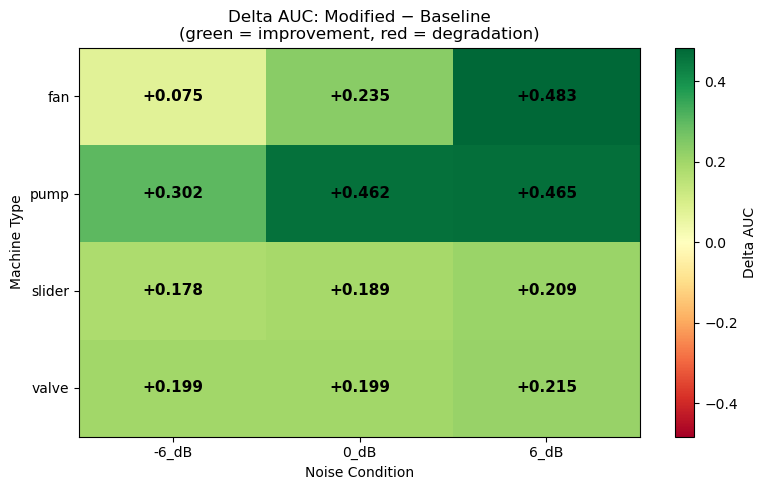

✓ Saved: phase5_delta_heatmap.png


In [6]:
# Average delta across both test machines per (machine_type, condition)
heatmap_data = comparison_df.groupby(['Machine', 'Condition'])['Delta AUC'].mean().unstack()
heatmap_data = heatmap_data.reindex(columns=['-6_dB', '0_dB', '6_dB'])

fig, ax = plt.subplots(figsize=(8, 5))
vmax = max(abs(heatmap_data.values.min()), abs(heatmap_data.values.max()))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto',
               vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel('Noise Condition')
ax.set_ylabel('Machine Type')
ax.set_title('Delta AUC: Modified − Baseline\n(green = improvement, red = degradation)')

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='black')

plt.colorbar(im, ax=ax, label='Delta AUC')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase5_delta_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Saved: phase5_delta_heatmap.png")

## Visualisation 2: Baseline vs Modified — Bar Chart by Machine Type

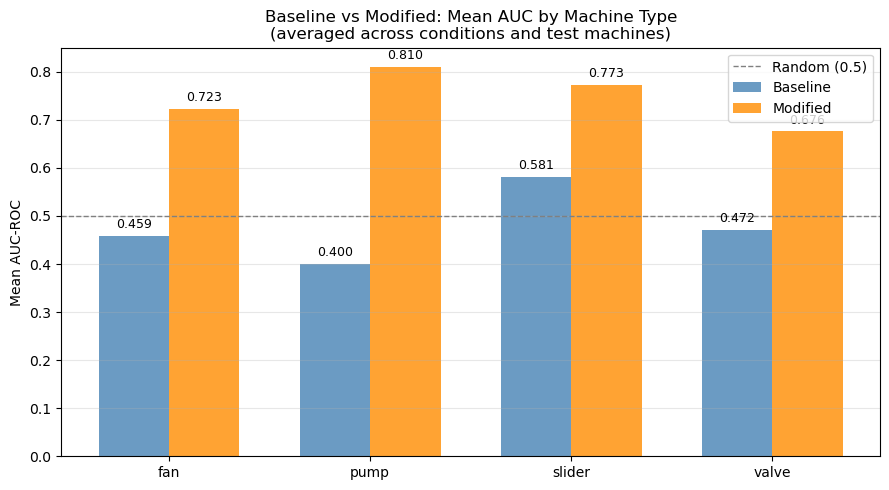

✓ Saved: phase5_baseline_vs_modified.png


In [7]:
machine_summary = comparison_df.groupby('Machine').agg(
    baseline_mean=('Baseline AUC', 'mean'),
    modified_mean=('Modified AUC', 'mean')
).reset_index()

x = np.arange(len(machine_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_b = ax.bar(x - width/2, machine_summary['baseline_mean'], width,
                label='Baseline', color='steelblue', alpha=0.8)
bars_m = ax.bar(x + width/2, machine_summary['modified_mean'], width,
                label='Modified', color='darkorange', alpha=0.8)

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Random (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(machine_summary['Machine'])
ax.set_ylabel('Mean AUC-ROC')
ax.set_title('Baseline vs Modified: Mean AUC by Machine Type\n(averaged across conditions and test machines)')
ax.set_ylim([0, 0.85])
ax.legend()
ax.grid(alpha=0.3, axis='y')

for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase5_baseline_vs_modified.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Saved: phase5_baseline_vs_modified.png")

## Visualisation 3: Scatter — Baseline vs Modified per Configuration

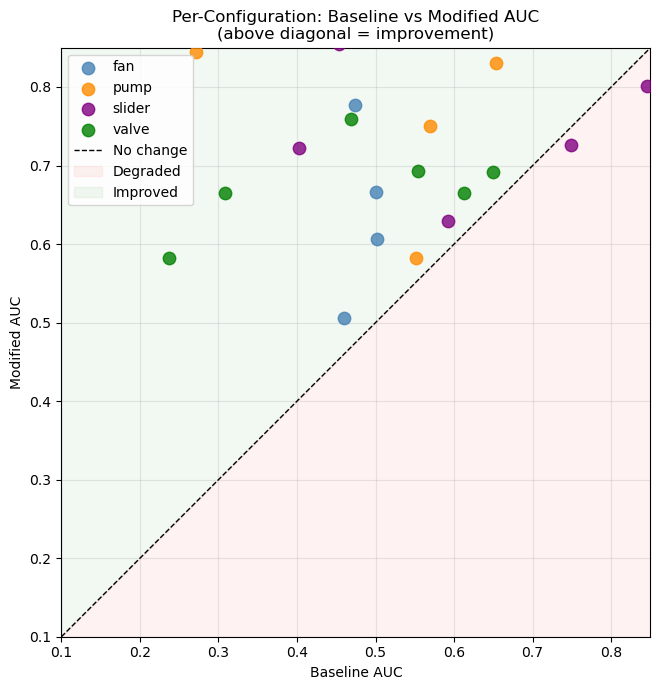

✓ Saved: phase5_scatter.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 7))

colors = {'fan': 'steelblue', 'pump': 'darkorange', 'valve': 'green', 'slider': 'purple'}
for machine, group in comparison_df.groupby('Machine'):
    ax.scatter(group['Baseline AUC'], group['Modified AUC'],
               color=colors[machine], label=machine, s=80, alpha=0.8, zorder=3)

# Diagonal — points above = improvement, below = degradation
lims = [0.1, 0.85]
ax.plot(lims, lims, 'k--', linewidth=1, label='No change', zorder=2)
ax.fill_between(lims, lims, [0.1, 0.1], alpha=0.05, color='red', label='Degraded')
ax.fill_between(lims, lims, [0.85, 0.85], alpha=0.05, color='green', label='Improved')

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Baseline AUC')
ax.set_ylabel('Modified AUC')
ax.set_title('Per-Configuration: Baseline vs Modified AUC\n(above diagonal = improvement)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'phase5_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Saved: phase5_scatter.png")

## Analysis: Where Did the Modifications Help Most?

In [9]:
print("TOP 5 IMPROVEMENTS:")
top_improved = comparison_df.nlargest(5, 'Delta AUC')[
    ['Machine', 'Condition', 'Test ID', 'Baseline AUC', 'Modified AUC', 'Delta AUC']
].round(4)
print(top_improved.to_string(index=False))

print("\nTOP 5 DEGRADATIONS:")
top_degraded = comparison_df.nsmallest(5, 'Delta AUC')[
    ['Machine', 'Condition', 'Test ID', 'Baseline AUC', 'Modified AUC', 'Delta AUC']
].round(4)
print(top_degraded.to_string(index=False))

print("\nDELTA BY MACHINE TYPE:")
delta_by_machine = comparison_df.groupby('Machine')['Delta AUC'].agg(['mean', 'std', 'min', 'max']).round(4)
print(delta_by_machine)

print("\nDELTA BY NOISE CONDITION:")
delta_by_condition = comparison_df.groupby('Condition')['Delta AUC'].agg(['mean', 'std', 'min', 'max']).round(4)
print(delta_by_condition)

TOP 5 IMPROVEMENTS:
Machine Condition Test ID  Baseline AUC  Modified AUC  Delta AUC
   pump      6_dB   id_04        0.1972        0.9504     0.7532
   pump      0_dB   id_04        0.1604        0.9022     0.7418
   pump     -6_dB   id_04        0.2711        0.8440     0.5729
    fan      6_dB   id_06        0.3459        0.9030     0.5571
 slider      6_dB   id_04        0.4406        0.9022     0.4616

TOP 5 DEGRADATIONS:
Machine Condition Test ID  Baseline AUC  Modified AUC  Delta AUC
 slider      6_dB   id_06        0.8458        0.8013    -0.0444
 slider      0_dB   id_06        0.7486        0.7257    -0.0230
   pump     -6_dB   id_06        0.5509        0.5818     0.0309
 slider     -6_dB   id_06        0.5927        0.6297     0.0370
  valve      0_dB   id_04        0.6495        0.6912     0.0418

DELTA BY MACHINE TYPE:
           mean     std     min     max
Machine                                
fan      0.2646  0.1955  0.0468  0.5571
pump     0.4096  0.3177  0.0309  0.

## Summary

In [10]:
mean_baseline = comparison_df['Baseline AUC'].mean()
mean_modified = comparison_df['Modified AUC'].mean()
mean_delta    = comparison_df['Delta AUC'].mean()
n_improved    = (comparison_df['Delta AUC'] > 0).sum()
n_total       = len(comparison_df)

print("="*60)
print("PHASE 5 SUMMARY")
print("="*60)
print(f"Mean baseline AUC:       {mean_baseline:.4f}")
print(f"Mean modified AUC:       {mean_modified:.4f}")
print(f"Mean delta:              {mean_delta:+.4f}")
print(f"Configurations improved: {n_improved}/{n_total}")
print()
print("Files saved:")
print("  phase5_comparison_results.csv")
print("  phase5_modified_results.pkl")
print("  phase5_delta_heatmap.png")
print("  phase5_baseline_vs_modified.png")
print("  phase5_scatter.png")

PHASE 5 SUMMARY
Mean baseline AUC:       0.4779
Mean modified AUC:       0.7455
Mean delta:              +0.2676
Configurations improved: 22/24

Files saved:
  phase5_comparison_results.csv
  phase5_modified_results.pkl
  phase5_delta_heatmap.png
  phase5_baseline_vs_modified.png
  phase5_scatter.png


## Graph: Baseline vs modified (by machine type and noise condition)

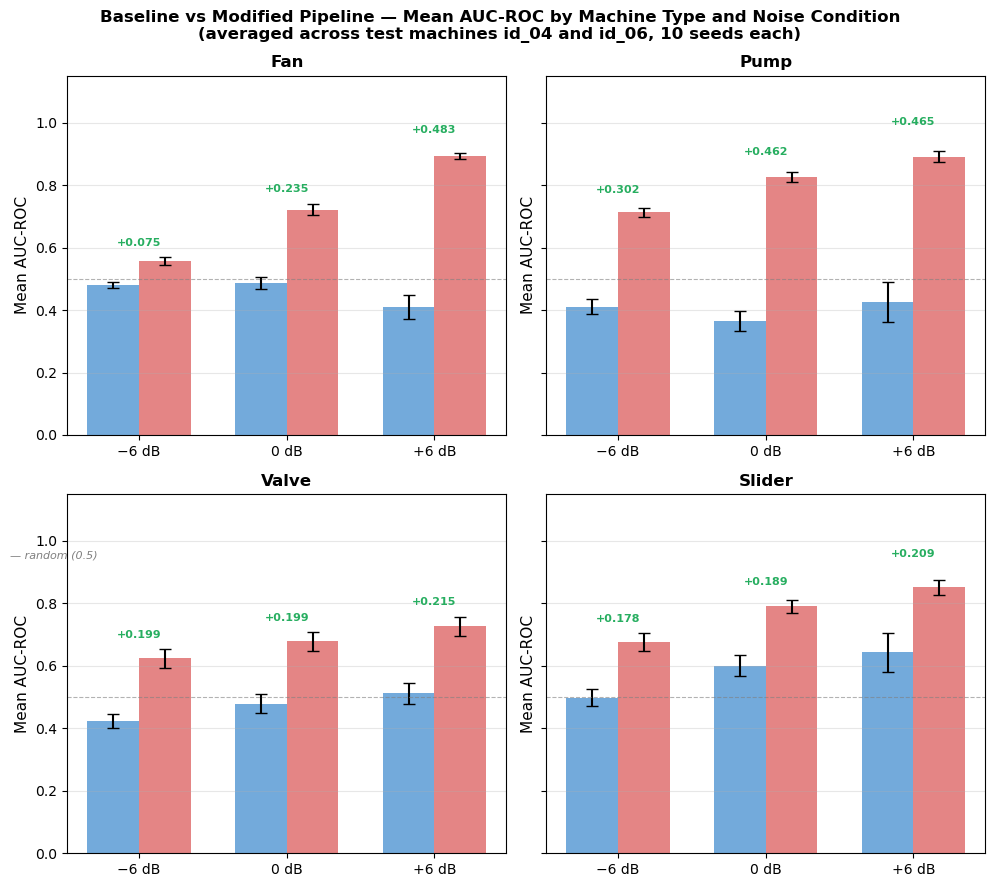

✓ Saved: C:\Users\Letizia\Documents\sound-anomaly-detection\results\figure_baseline_vs_modified_by_condition.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

machine_order    = ['fan', 'pump', 'valve', 'slider']
condition_order  = ['-6_dB', '0_dB', '6_dB']
condition_labels = ['−6 dB', '0 dB', '+6 dB']

fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharey=True)
axes = axes.flatten()
fig.suptitle(
    'Baseline vs Modified Pipeline — Mean AUC-ROC by Machine Type and Noise Condition\n'
    '(averaged across test machines id_04 and id_06, 10 seeds each)',
    fontsize=12, fontweight='bold'
)

bar_width = 0.35
x = np.arange(len(condition_order))

for i, (ax, machine) in enumerate(zip(axes, machine_order)):
    baseline_means, modified_means = [], []
    baseline_stds,  modified_stds  = [], []

    for cond in condition_order:
        subset = comparison_df[
            (comparison_df['Machine'] == machine) &
            (comparison_df['Condition'] == cond)
        ]
        baseline_means.append(subset['Baseline AUC'].mean())
        modified_means.append(subset['Modified AUC'].mean())
        baseline_stds.append(subset['Baseline Std'].mean())
        modified_stds.append(subset['Modified Std'].mean())

    b1 = ax.bar(x - bar_width/2, baseline_means, bar_width,
                yerr=baseline_stds, label='Baseline',
                color='#5B9BD5', alpha=0.85, capsize=4,
                error_kw={'linewidth': 1.5})
    b2 = ax.bar(x + bar_width/2, modified_means, bar_width,
                yerr=modified_stds, label='Modified',
                color='#E07070', alpha=0.85, capsize=4,
                error_kw={'linewidth': 1.5})

    for i, (bm, mm) in enumerate(zip(baseline_means, modified_means)):
        delta = mm - bm
        top = max(bm, mm) + max(baseline_stds[i], modified_stds[i]) + 0.03
        color = '#27AE60' if delta >= 0 else '#C0392B'
        ax.text(x[i], min(top, 1.06),
                f'{delta:+.3f}',
                ha='center', va='bottom', fontsize=8,
                color=color, fontweight='bold')

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_title(machine.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(condition_labels, fontsize=10)
    ax.set_ylim([0, 1.15])
    ax.grid(axis='y', alpha=0.3)
    if i == 0 or i == 2:
        ax.set_ylabel('Mean AUC-ROC', fontsize=11)
    if i == 0:
        ax.legend(fontsize=9, loc='upper left')

# Random baseline label
fig.text(0.01, 0.37, '— random (0.5)', fontsize=8, color='gray', style='italic')

plt.tight_layout()
fig_path = RESULTS_DIR / 'figure_baseline_vs_modified_by_condition.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved: {fig_path}')